In [5]:
from google.colab import drive
# force_remount=True를 넣어주면 기존 연결이 꼬였을 때 새로고침해줍니다.
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
import os

# 1. 파일이 진짜 있는지 다시 한 번 체크
zip_path = "/content/drive/MyDrive/Gunshot_Dataset_Final.zip"

if os.path.exists(zip_path):
    print("✅ 파일을 찾았습니다! 압축을 해제합니다...")
    # 압축 해제 (기존에 풀다 말았던 찌꺼기가 있을 수 있으니 -o 옵션으로 덮어쓰기)
    !unzip -qo "{zip_path}" -d "/content/dataset"
    print("✨ 압축 해제 완료!")
else:
    print("❌ 에러: 파일을 찾을 수 없습니다. 드라이브 내 파일명을 다시 확인해주세요.")
    # 실제 드라이브에 있는 파일들 목록을 보여줍니다 (이름 확인용)
    print("현재 드라이브 파일 목록:", os.listdir("/content/drive/MyDrive/"))

# 2. 데이터 개수 최종 확인
if os.path.exists("/content/dataset/train/entrance"):
    ent_count = len(os.listdir("/content/dataset/train/entrance"))
    exit_count = len(os.listdir("/content/dataset/train/exit"))
    print(f"\n--- 데이터 로드 성공 ---")
    print(f"학습용 자입구(Entrance): {ent_count}개")
    print(f"학습용 사출구(Exit): {exit_count}개")

✅ 파일을 찾았습니다! 압축을 해제합니다...
✨ 압축 해제 완료!

--- 데이터 로드 성공 ---
학습용 자입구(Entrance): 1318개
학습용 사출구(Exit): 469개


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# 1. 이미지 전처리 및 데이터 로더 설정
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(), # 데이터 증강: 좌우 반전
        transforms.RandomRotation(10),     # 데이터 증강: 살짝 회전
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # 밝기/대비 조절
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder('/content/dataset/train', data_transforms['train']),
    'val': datasets.ImageFolder('/content/dataset/val', data_transforms['val'])
}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True) for x in ['train', 'val']}
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 2. 모델 설정: ResNet50 (전이 학습)
model = models.resnet50(weights='IMAGENET1K_V2')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) # Entrance vs Exit 이진 분류
model = model.to(device)

# 3. 손실 함수 (가중치 적용) 및 최적화 설정
# Exit(사출구) 데이터가 적으므로 맞혔을 때 보상을 크게 줍니다.
weights = torch.tensor([1.0, 2.8]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 4. 학습 루프
print(f"사용 중인 장치: {device}")
print("학습을 시작합니다. 약 10분 정도 소요됩니다...")

for epoch in range(10):
    model.train()
    running_loss = 0.0

    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(image_datasets['train'])

    # 검증(Validation)
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    val_acc = val_corrects.double() / len(image_datasets['val'])
    print(f"Epoch {epoch+1}/10 | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f}")

# 5. 모델 저장
torch.save(model.state_dict(), "/content/drive/MyDrive/gunshot_resnet50_v1.pth")
print("\n✅ 학습 완료! 모델이 구글 드라이브에 저장되었습니다.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


사용 중인 장치: cuda:0
학습을 시작합니다. 약 10분 정도 소요됩니다...
Epoch 1/10 | Loss: 0.5773 | Val Acc: 0.8298
Epoch 2/10 | Loss: 0.3407 | Val Acc: 0.8717
Epoch 3/10 | Loss: 0.2179 | Val Acc: 0.8770
Epoch 4/10 | Loss: 0.1471 | Val Acc: 0.8691
Epoch 5/10 | Loss: 0.1165 | Val Acc: 0.8953
Epoch 6/10 | Loss: 0.0955 | Val Acc: 0.8770
Epoch 7/10 | Loss: 0.0809 | Val Acc: 0.9136
Epoch 8/10 | Loss: 0.0597 | Val Acc: 0.8901
Epoch 9/10 | Loss: 0.0543 | Val Acc: 0.8979
Epoch 10/10 | Loss: 0.0483 | Val Acc: 0.9267

✅ 학습 완료! 모델이 구글 드라이브에 저장되었습니다.


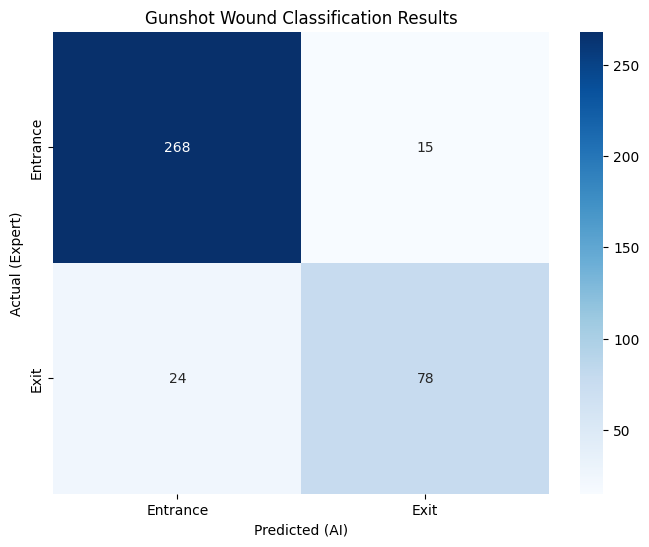


--- 상세 분류 리포트 ---
              precision    recall  f1-score   support

    Entrance       0.92      0.95      0.93       283
        Exit       0.84      0.76      0.80       102

    accuracy                           0.90       385
   macro avg       0.88      0.86      0.87       385
weighted avg       0.90      0.90      0.90       385



In [8]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 테스트 데이터 로더 설정
test_dataset = datasets.ImageFolder('/content/dataset/test', data_transforms['val'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. 예측 수행
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Entrance', 'Exit'],
            yticklabels=['Entrance', 'Exit'])
plt.xlabel('Predicted (AI)')
plt.ylabel('Actual (Expert)')
plt.title('Gunshot Wound Classification Results')
plt.show()

print("\n--- 상세 분류 리포트 ---")
print(classification_report(all_labels, all_preds, target_names=['Entrance', 'Exit']))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=f1cddd24179f26db58385b291b8497314d5f550ae6e619e1882583633c5327d0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


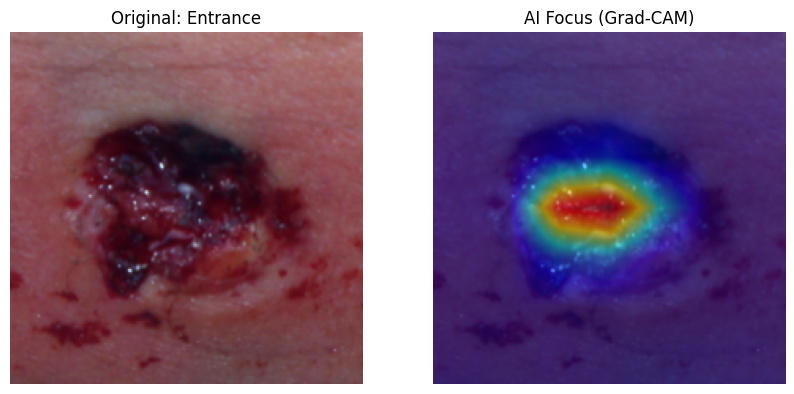

In [9]:
# 1. Grad-CAM 라이브러리 설치
!pip install grad-cam

import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 2. 시각화 대상 레이어 지정 (ResNet50의 마지막 컨볼루션 레이어)
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# 3. 테스트 이미지 중 하나를 선택해서 시각화
# test_dataset[index]에서 index 숫자를 바꿔가며 여러 장 확인해보세요.
image, label = test_dataset[10]
input_tensor = image.unsqueeze(0).to(device)

# 가중치 계산 및 히트맵 생성
targets = [ClassifierOutputTarget(label)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# 원본 이미지 역정규화 (시각화용)
img_np = image.permute(1, 2, 0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

# 이미지 위에 히트맵 덮어쓰기
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

# 결과 출력
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title(f"Original: {'Entrance' if label==0 else 'Exit'}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("AI Focus (Grad-CAM)")
plt.axis('off')
plt.show()